## Import The Libraries

In [ ]:
!pip install ultralytics

In [2]:
import os
import yaml
import random
import cv2
import matplotlib.pyplot as plt
from glob import glob
from ultralytics import YOLO
import pandas as pd

In [4]:
class Sys:
    EPOCHS = 5 # Atleast 50
    BATCH_SIZE = 32
    SEED = 6
    LEARNING_RATE = 0.001
    OPTIMIZER = "Adam"
    TRAIN_IMAGES = "dataset/train/images"
    VALID_IMAGES = "dataset/valid/images"
    TEST_IMAGES = "dataset/test/images"
    OUTPUT_DIR = "ft_models"
    NUM_SAMPLES = 16  # Number of random images for visualization

In [5]:
data_config = {
    "train": Sys.TRAIN_IMAGES,
    "val": Sys.VALID_IMAGES,
    "test": Sys.TEST_IMAGES,
    "nc": 1,  # Number of classes
    "names": ["Kidney_Stone"],  # Class names
}

In [6]:
yaml_file_path = "temp_data.yaml"
with open(yaml_file_path, "w") as file:
    yaml.dump(data_config, file)


In [7]:
def visualize_images(image_folder, num_samples=16):
    image_files = glob(f"{image_folder}/*")
    selected_images = random.sample(image_files, num_samples)
    plt.figure(figsize=(12, 10))
    for i, img_path in enumerate(selected_images):
        plt.subplot(4, 4, i + 1)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img)
        plt.axis('off')
    plt.show()

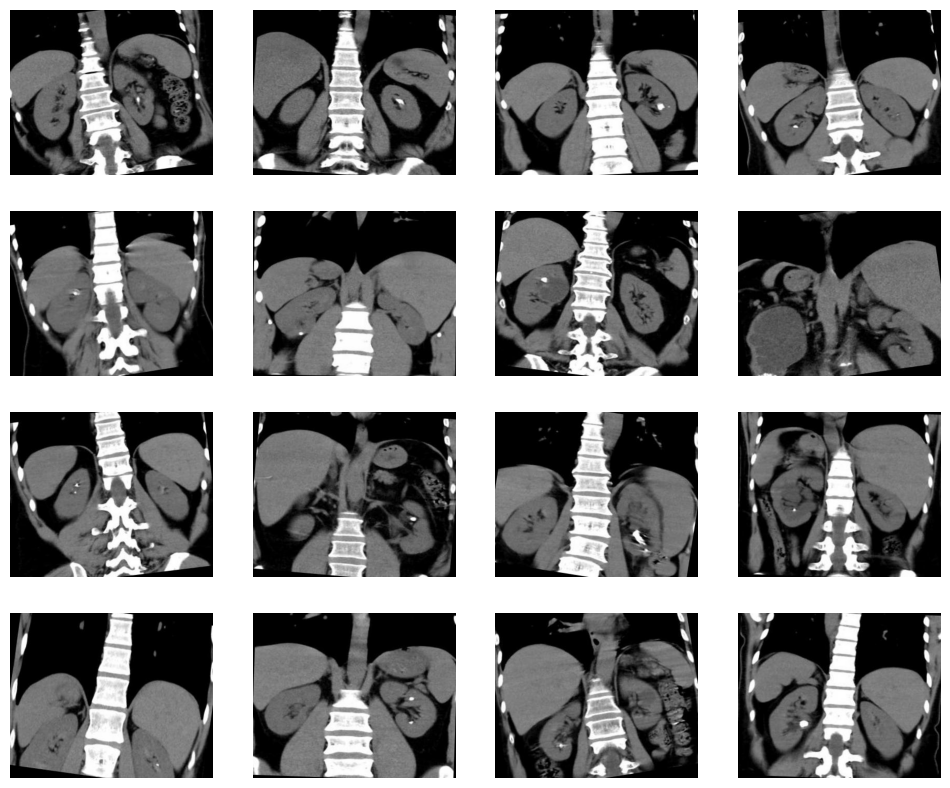

In [8]:
visualize_images(Sys.TRAIN_IMAGES)

In [9]:
model = YOLO("yolov8m.pt")  # Pretrained YOLOv8 model

In [ ]:
model.train(
    data=yaml_file_path,
    seed=Sys.SEED,
    epochs=Sys.EPOCHS,
    lr0=Sys.LEARNING_RATE,
    optimizer=Sys.OPTIMIZER,
    project=Sys.OUTPUT_DIR,
    name="kidney_stone_detection",
    verbose=True,
)

Ultralytics 8.3.55 🚀 Python-3.12.3 torch-2.5.1+cu124 CPU (11th Gen Intel Core(TM) i5-1135G7 2.40GHz)
engine/trainer: task=detect, mode=train, model=yolov8m.pt, data=temp_data.yaml, epochs=5, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=ft_models, name=kidney_stone_detection5, exist_ok=False, pretrained=True, optimizer=Adam, verbose=True, seed=6, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=Tru

train: Scanning /home/huzbntu/Stuff/cui/F/Eisha/fyp/doc-link-fyp/ml_models/kidney_stone_detection/using_yolo/dataset/train/labels.cache... 1054 images, 1 backgrounds, 0 corrupt: 100%|██████████| 1054/1054 [00:00<?, ?it/s]
val: Scanning /home/huzbntu/Stuff/cui/F/Eisha/fyp/doc-link-fyp/ml_models/kidney_stone_detection/using_yolo/dataset/valid/labels.cache... 123 images, 0 backgrounds, 0 corrupt: 100%|██████████| 123/123 [00:00<?, ?it/s]


Plotting labels to ft_models/kidney_stone_detection5/labels.jpg... 
optimizer: Adam(lr=0.001, momentum=0.937) with parameter groups 77 weight(decay=0.0), 84 weight(decay=0.0005), 83 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 0 dataloader workers
Logging results to ft_models/kidney_stone_detection5
Starting training for 5 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


        1/5         0G      2.136      1.548      1.304         61        640: 100%|██████████| 66/66 [39:06<00:00, 35.55s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [01:22<00:00, 20.50s/it]

                   all        123        325      0.649      0.289      0.376      0.147



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


        2/5         0G      2.128       1.24      1.298         37        640: 100%|██████████| 66/66 [38:39<00:00, 35.14s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [01:18<00:00, 19.55s/it]

                   all        123        325      0.726      0.588      0.613      0.214



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


        3/5         0G      2.087      1.126       1.28         52        640:  64%|██████▎   | 42/66 [25:48<15:41, 39.22s/it]

In [ ]:
# Cleanup the temporary YAML file if needed
import os
os.remove(yaml_file_path)

In [ ]:
# Save the trained model for future use
trained_model_path = f"{Sys.OUTPUT_DIR}/kidney_stone_detection/weights/best.pt"
model_trained = YOLO(trained_model_path)

In [ ]:
def stone_detection(img_path, model):
    img = cv2.imread(img_path)
    detect_result = model(img)
    detect_img = detect_result[0].plot()
    detect_img = cv2.cvtColor(detect_img, cv2.COLOR_BGR2RGB)
    return detect_img

In [ ]:
test_images_path = Sys.TEST_IMAGES
test_images = os.listdir(test_images_path)
selected_images = random.sample(test_images, Sys.NUM_SAMPLES)

In [ ]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(15, 15))
for i, img_file in enumerate(selected_images):
    row_idx = i // 4
    col_idx = i % 4
    img_path = os.path.join(test_images_path, img_file)
    detect_img = stone_detection(img_path, model_trained)
    axes[row_idx, col_idx].imshow(detect_img)
    axes[row_idx, col_idx].axis("off")
plt.subplots_adjust(wspace=0.05, hspace=0.05)
plt.show()

In [ ]:
export_model_path = "kidney_stone_model.onnx"
model_trained.export(format="onnx", path=export_model_path)
print(f"Trained model exported to: {export_model_path}")